# EDA — Previsão de precipitação sobre a América do Sul

Este notebook plota os gráficos da análise exploratória. Os cálculos pesados (estatísticas por variável, médias espaciais, correlações) reaproveitam as funções de `download_data.py` e `eda.py` — rode `python3 eda.py` antes para gerar o cache em `eda_output/` (opcional: se não existir, este notebook calcula na hora).

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scripts.download_data import download_competition_data, load_dataset_files
from scripts.eda import variable_summary, spatial_mean_frame

OUTPUT_DIR = "eda_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Carregar os dados

Baixa (ou reaproveita o cache local do `kagglehub`) e abre os arquivos `.csv`/`.nc`.

In [2]:
path = download_competition_data()
dataframes, datasets = load_dataset_files(path)

treino_names = sorted(n for n in datasets if n.startswith("treino_"))
treino_names

Path to competition files: /home/mazeeqe/.cache/kagglehub/competitions/previsao-climatica-de-precipitacao-sobre-a-america-do-sul
Carregado 'sample_submission' (csv): 1885464 linhas x 2 colunas
Carregado 'teste_features' (netcdf): dims=(time=24, lat=301, lon=261), variáveis=['t2', 'cloud_cover', 'shum_850', 'surface_pressure', 'u_850', 'v_850', 'temperature_850', 'rel_hum_850', 'geopotential_850', 'tp_alvo', 'tp_ultima_obs']
Carregado 'treino_cloud_cover' (netcdf): dims=(time=996, lat=301, lon=261), variáveis=['cloud_cover']
Carregado 'treino_geopotential_850' (netcdf): dims=(time=996, lat=301, lon=261), variáveis=['geopotential_850']
Carregado 'treino_rel_hum_850' (netcdf): dims=(time=996, lat=301, lon=261), variáveis=['rel_hum_850']
Carregado 'treino_shum_850' (netcdf): dims=(time=996, lat=301, lon=261), variáveis=['shum_850']
Carregado 'treino_surface_pressure' (netcdf): dims=(time=996, lat=301, lon=261), variáveis=['surface_pressure']
Carregado 'treino_t2' (netcdf): dims=(time=996, 

['treino_cloud_cover',
 'treino_geopotential_850',
 'treino_rel_hum_850',
 'treino_shum_850',
 'treino_surface_pressure',
 'treino_t2',
 'treino_temperature_850',
 'treino_tp',
 'treino_tp_alvo',
 'treino_u_850',
 'treino_v_850']

## 2. Resumo estatístico por variável

Min, max, média, desvio-padrão e % de dados faltantes de cada variável (ver `eda.py` para detalhes de por que a média/desvio são calculados em `float64`).

In [3]:
summary_path = os.path.join(OUTPUT_DIR, "resumo_variaveis.csv")
if os.path.exists(summary_path):
    summary = pd.read_csv(summary_path)
else:
    summary = variable_summary(datasets)
    summary.to_csv(summary_path, index=False)

summary

,dataset,variavel,min,max,media,desvio_padrao,pct_faltante,tempo_inicio,tempo_fim
0,teste_features,t2,257.502441,307.299072,291.663584,8.906699,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
1,teste_features,cloud_cover,0.000425,0.989929,0.630714,0.181253,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
2,teste_features,shum_850,0.000496,0.015163,0.007079,0.003998,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
3,teste_features,surface_pressure,54592.304688,102806.671875,99156.992457,5658.858785,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
4,teste_features,u_850,-17.798294,23.206375,1.400699,6.735648,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
5,teste_features,v_850,-14.501475,11.069153,-0.224760,2.394585,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
6,teste_features,temperature_850,257.812500,298.855225,284.586685,8.563338,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
7,teste_features,rel_hum_850,2.814855,99.347977,64.596658,16.722143,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
8,teste_features,geopotential_850,10559.785156,15602.886719,14454.563377,871.351305,0.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000
9,teste_features,tp_alvo,NaN,NaN,NaN,NaN,100.000000,2023-01-01T00:00:00.000000000,2024-12-01T00:00:00.000000000


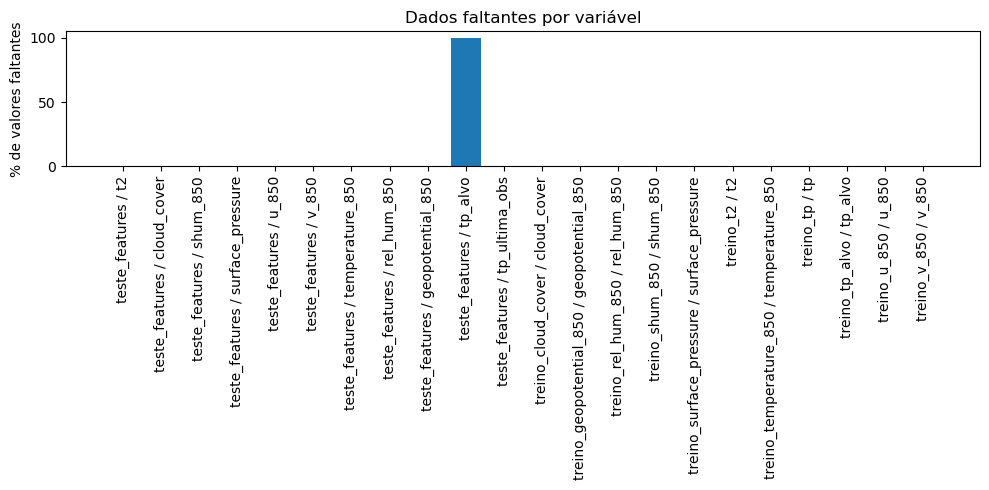

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
rotulos = summary["dataset"] + " / " + summary["variavel"]
ax.bar(rotulos, summary["pct_faltante"])
ax.set_ylabel("% de valores faltantes")
ax.set_title("Dados faltantes por variável")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Correlação entre variáveis (treino)

Correlação calculada sobre a média espacial (lat/lon) de cada variável em cada mês.

In [5]:
series_path = os.path.join(OUTPUT_DIR, "series_temporais_treino.csv")
if os.path.exists(series_path):
    treino_frame = pd.read_csv(series_path, index_col=0, parse_dates=True)
else:
    treino_frame = spatial_mean_frame(datasets, treino_names)
    treino_frame.to_csv(series_path)

treino_corr = treino_frame.corr()
treino_corr

,cloud_cover,geopotential_850,rel_hum_850,shum_850,surface_pressure,t2,temperature_850,tp,tp_alvo,u_850,v_850
cloud_cover,1.000000,-0.282080,0.373975,0.463739,-0.387901,0.350206,0.367356,0.663994,0.542445,-0.262690,-0.283864
geopotential_850,-0.282080,1.000000,-0.253527,-0.292701,0.852043,-0.240849,-0.236329,-0.341958,-0.285570,-0.203072,0.265294
rel_hum_850,0.373975,-0.253527,1.000000,0.645163,-0.421525,0.429854,0.314086,0.699483,0.416785,-0.380933,-0.249080
shum_850,0.463739,-0.292701,0.645163,1.000000,-0.726099,0.952249,0.919094,0.742639,0.754173,-0.341761,-0.654382
surface_pressure,-0.387901,0.852043,-0.421525,-0.726099,1.000000,-0.708914,-0.701876,-0.588607,-0.599753,-0.004932,0.569728
t2,0.350206,-0.240849,0.429854,0.952249,-0.708914,1.000000,0.982716,0.619840,0.748150,-0.270276,-0.683684
temperature_850,0.367356,-0.236329,0.314086,0.919094,-0.701876,0.982716,1.000000,0.569763,0.727967,-0.237684,-0.711978
tp,0.663994,-0.341958,0.699483,0.742639,-0.588607,0.619840,0.569763,1.000000,0.648637,-0.360067,-0.481858
tp_alvo,0.542445,-0.285570,0.416785,0.754173,-0.599753,0.748150,0.727967,0.648637,1.000000,-0.168146,-0.484284
u_850,-0.262690,-0.203072,-0.380933,-0.341761,-0.004932,-0.270276,-0.237684,-0.360067,-0.168146,1.000000,0.239913


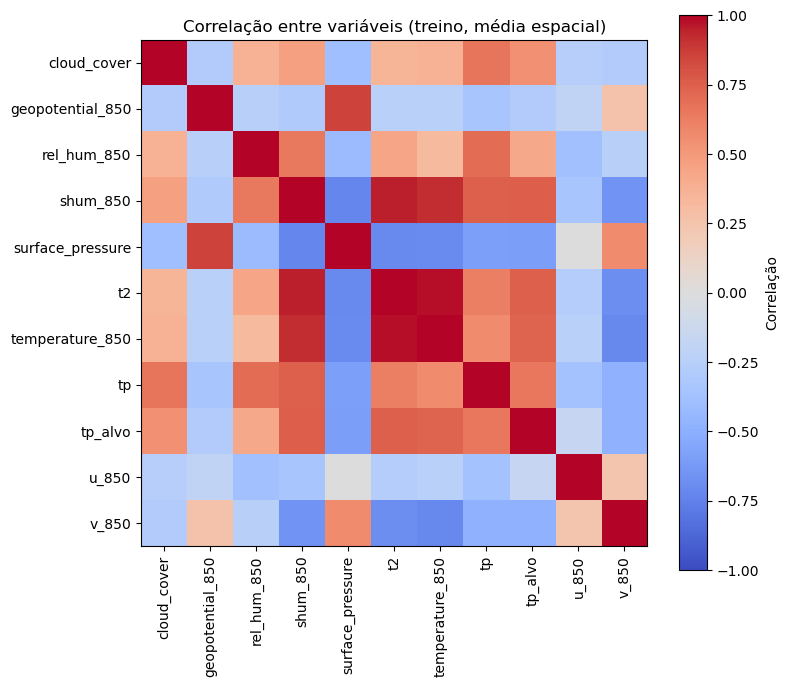

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(treino_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(treino_corr.columns)))
ax.set_xticklabels(treino_corr.columns, rotation=90)
ax.set_yticks(range(len(treino_corr.columns)))
ax.set_yticklabels(treino_corr.columns)
fig.colorbar(im, ax=ax, label="Correlação")
ax.set_title("Correlação entre variáveis (treino, média espacial)")
plt.tight_layout()
plt.show()

## 4. Séries temporais (médias espaciais anuais)

Agregando por ano para deixar a sazonalidade mensal de lado e ver tendência de longo prazo.

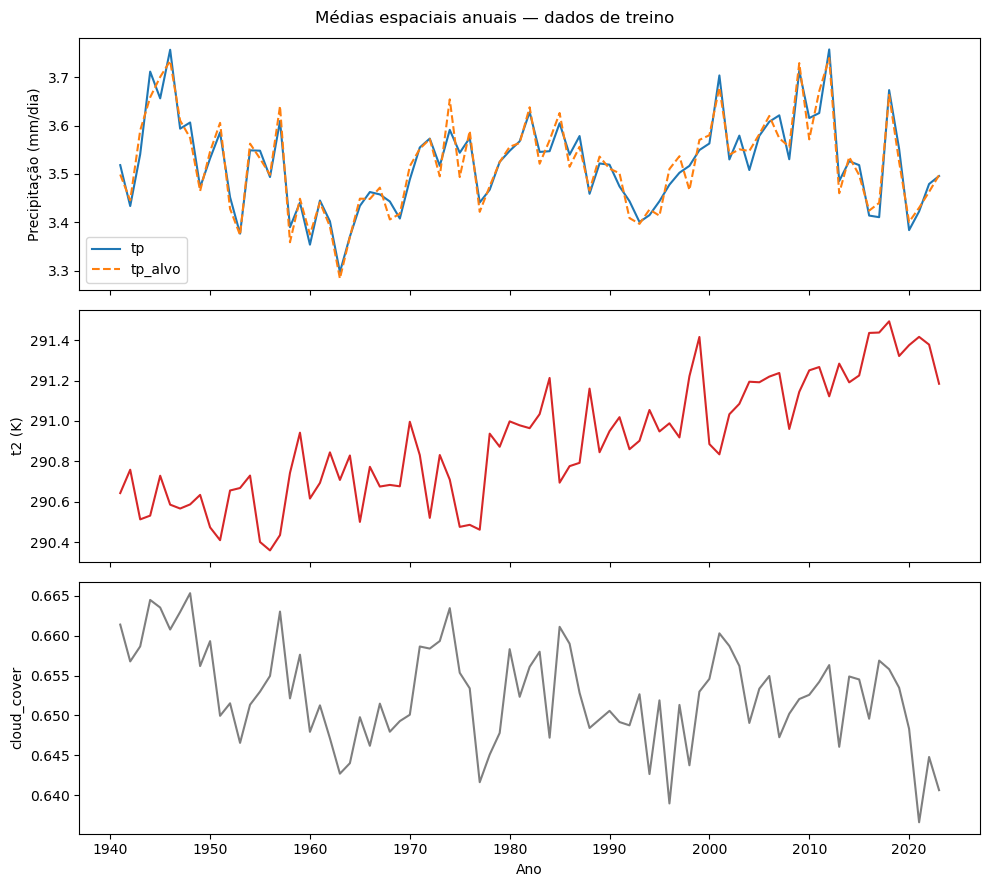

In [7]:
anual = treino_frame.resample("YE").mean()

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(anual.index, anual["tp"], label="tp")
axes[0].plot(anual.index, anual["tp_alvo"], label="tp_alvo", linestyle="--")
axes[0].set_ylabel("Precipitação (mm/dia)")
axes[0].legend()

axes[1].plot(anual.index, anual["t2"], color="tab:red")
axes[1].set_ylabel("t2 (K)")

axes[2].plot(anual.index, anual["cloud_cover"], color="tab:gray")
axes[2].set_ylabel("cloud_cover")
axes[2].set_xlabel("Ano")

fig.suptitle("Médias espaciais anuais — dados de treino")
plt.tight_layout()
plt.show()

## 5. Distribuição da precipitação-alvo (`tp_alvo`)

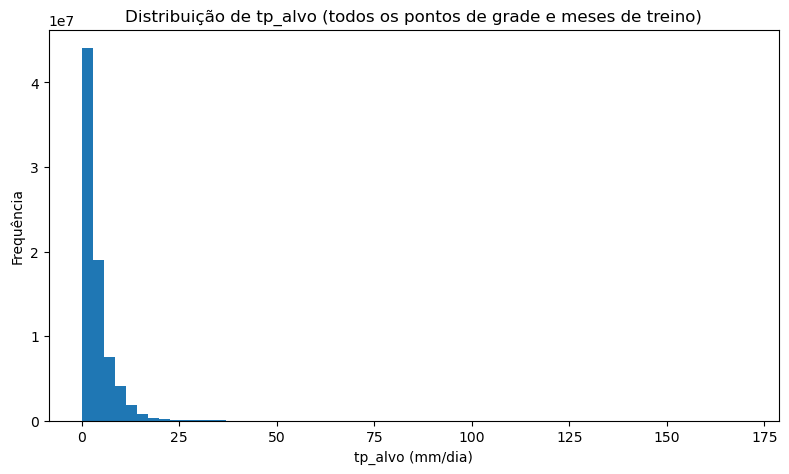

In [8]:
tp_alvo = datasets["treino_tp_alvo"]["tp_alvo"].values.ravel()
tp_alvo = tp_alvo[~np.isnan(tp_alvo)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tp_alvo, bins=60)
ax.set_xlabel("tp_alvo (mm/dia)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de tp_alvo (todos os pontos de grade e meses de treino)")
plt.tight_layout()
plt.show()

## 6. Mapas espaciais (média no tempo)

Média (float64) de cada variável ao longo de todo o período de treino, ponto a ponto.

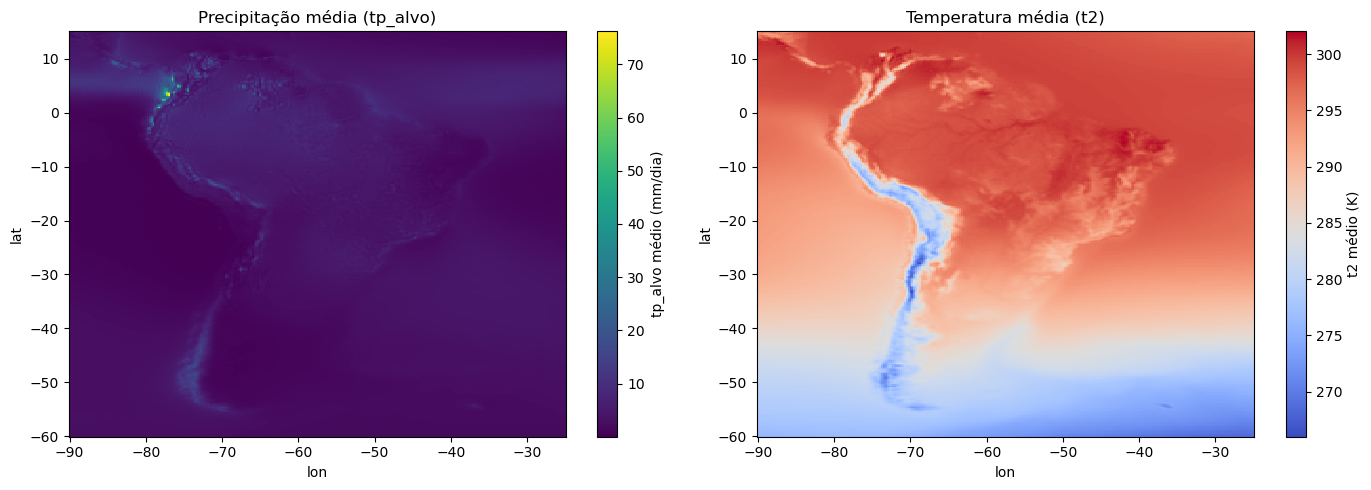

In [9]:
mapa_tp_alvo = datasets["treino_tp_alvo"]["tp_alvo"].mean(dim="time", skipna=True, dtype="float64")
mapa_t2 = datasets["treino_t2"]["t2"].mean(dim="time", skipna=True, dtype="float64")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mapa_tp_alvo.plot(ax=axes[0], cmap="viridis", cbar_kwargs={"label": "tp_alvo médio (mm/dia)"})
axes[0].set_title("Precipitação média (tp_alvo)")

mapa_t2.plot(ax=axes[1], cmap="coolwarm", cbar_kwargs={"label": "t2 médio (K)"})
axes[1].set_title("Temperatura média (t2)")

plt.tight_layout()
plt.show()